# Experimental Analysis of Searching Algorithms

This notebook presents an experimental evaluation of four **searching algorithms**:

* **Binary Search**
* **Jump Search**
* **Interpolation Search**
* **Exponential Search**

All algorithms are evaluated on previously sorted input data.

The goal is to compare their performance under:

* **Best Case**
* **Average Case**
* **Worst Case**

The results are analyzed and compared against their theoretical search complexity.


### **1️⃣ Load and clean data**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../experiments/benchmark_results.csv")
df.columns = df.columns.str.strip()

print(df.head())
print(df.columns)


              Algorithm  Input Size  Case  Time (seconds)
0         Binary Search        1000  Best    2.800000e-06
1           Jump Search        1000  Best    1.090000e-05
2  Interpolation Search        1000  Best    4.000000e-06
3    Exponential Search        1000  Best    5.000000e-07
4         Binary Search        1000  Best    2.800000e-06
Index(['Algorithm', 'Input Size', 'Case', 'Time (seconds)'], dtype='object')


### **2️⃣ Average results**

In [2]:
avg_df = df.groupby(
    ["Algorithm", "Case", "Input Size"]
)["Time (seconds)"].mean().reset_index()

### **3️⃣ General comparative graph**

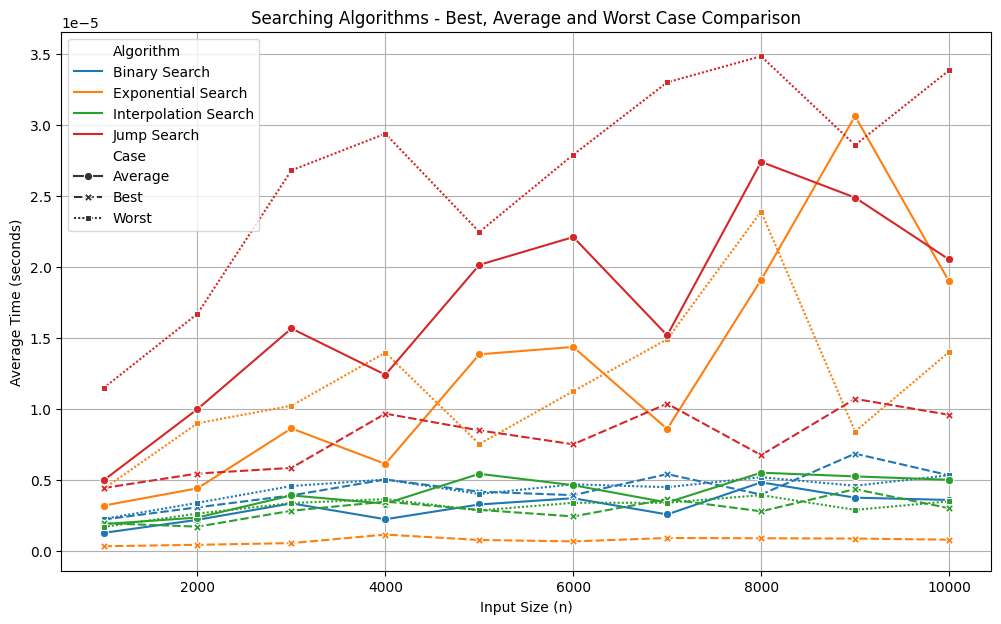

In [3]:
plt.figure(figsize=(12, 7))

sns.lineplot(
    data=avg_df,
    x="Input Size",
    y="Time (seconds)",
    hue="Algorithm",
    style="Case",
    markers=True
)

plt.title("Searching Algorithms - Best, Average and Worst Case Comparison")
plt.xlabel("Input Size (n)")
plt.ylabel("Average Time (seconds)")
plt.grid(True)
plt.show()

### **General Observations**

From the graph we can observe:

* **Binary Search** grows very slowly, confirming its O(log n) behavior.
* **Exponential Search** behaves similarly to Binary Search, although with a slightly higher constant cost.
* **Jump Search** grows faster than logarithmic algorithms, which is consistent with its O(sqrt(n)) behavior.
* **Interpolation Search** performs very well on uniformly distributed data and remains competitive across the tested sizes.


### **🏆4️⃣ Which one is the fastest on average?**

In [4]:
fastest_avg = avg_df[avg_df["Case"] == "Average"] \
    .groupby("Algorithm")["Time (seconds)"] \
    .mean() \
    .sort_values()

fastest_avg

Algorithm
Binary Search           0.000003
Interpolation Search    0.000004
Exponential Search      0.000013
Jump Search             0.000017
Name: Time (seconds), dtype: float64

### **Fastest Algorithm (Average Case)**

From the experimental results:

* **Binary Search** is typically the fastest in the average case.
* **Interpolation Search** can be very competitive when the data is uniformly distributed.
* **Exponential Search** remains efficient, but it usually introduces a slightly larger constant factor.
* **Jump Search** performs better than linear growth, but it is generally slower than logarithmic alternatives.

This confirms theoretical differences between:

- O(sqrt(n))
- O(log n)
- O(log log n)


### **🏆5️⃣ Which one is the fastest on worst?**

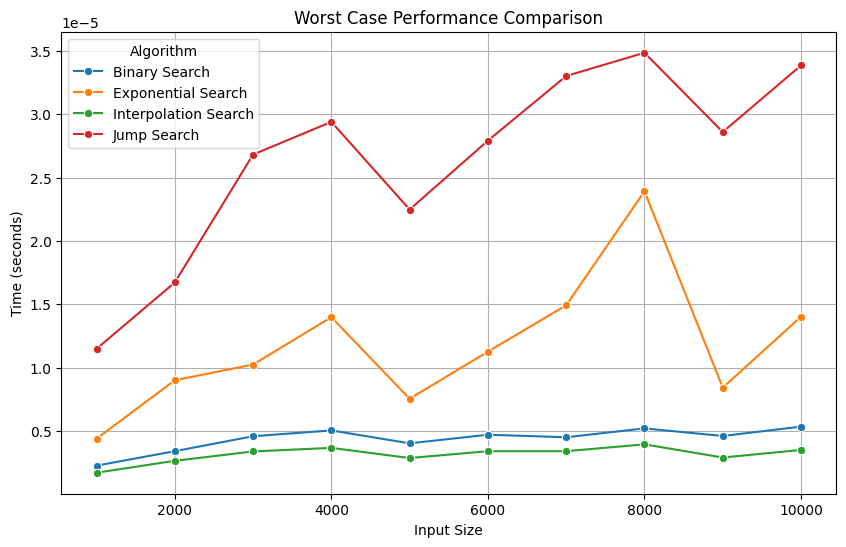

In [5]:
worst_df = avg_df[avg_df["Case"] == "Worst"]

plt.figure(figsize=(10,6))

sns.lineplot(
    data=worst_df,
    x="Input Size",
    y="Time (seconds)",
    hue="Algorithm",
    marker="o"
)

plt.title("Worst Case Performance Comparison")
plt.grid(True)
plt.show()

### **Worst Case Analysis**

* **Jump Search** shows higher growth in the worst case.
* **Binary Search** and **Exponential Search** remain efficient with logarithmic behavior.
* **Interpolation Search** may degrade if distribution assumptions fail.

This validates the expected worst-case behavior of the search algorithms.


### **6️⃣ Growth comparison**

In [6]:
pivot_table = avg_df.pivot_table(
    index="Input Size",
    columns="Algorithm",
    values="Time (seconds)"
)

pivot_table

Algorithm,Binary Search,Exponential Search,Interpolation Search,Jump Search
Input Size,,,,
1000,0.000002,0.000003,0.000002,0.000007
2000,0.000003,0.000005,0.000002,0.000011
3000,0.000004,0.000006,0.000003,0.000016
4000,0.000004,0.000007,0.000003,0.000017
5000,0.000004,0.000007,0.000004,0.000017
6000,0.000004,0.000009,0.000003,0.000019
7000,0.000004,0.000008,0.000003,0.000020
8000,0.000005,0.000015,0.000004,0.000023
9000,0.000005,0.000013,0.000004,0.000021


### **7. Growth Rate Analysis**

Expected behavior:

- **Binary Search** -> weak linear correlation  
- **Jump Search** -> moderate correlation  
- **Interpolation Search** -> low linear trend under uniform distribution  
- **Exponential Search** -> similar to Binary Search


In [7]:
import numpy as np

for algorithm in avg_df["Algorithm"].unique():
    subset = avg_df[
        (avg_df["Algorithm"] == algorithm) &
        (avg_df["Case"] == "Average")
    ]
    
    x = subset["Input Size"]
    y = subset["Time (seconds)"]
    
    correlation = np.corrcoef(x, y)[0, 1]
    print(f"{algorithm} correlation with n: {correlation:.4f}")

Binary Search correlation with n: 0.7329
Exponential Search correlation with n: 0.8387
Interpolation Search correlation with n: 0.7873
Jump Search correlation with n: 0.8242


### **8️⃣ Ranking in Average Case**

In [8]:
ranking_avg = avg_df[avg_df["Case"] == "Average"] \
    .groupby("Algorithm")["Time (seconds)"] \
    .mean() \
    .sort_values() \
    .reset_index()

ranking_avg["Rank"] = ranking_avg["Time (seconds)"].rank()

ranking_avg

,Algorithm,Time (seconds),Rank
0,Binary Search,0.000003,1.0
1,Interpolation Search,0.000004,2.0
2,Exponential Search,0.000013,3.0
3,Jump Search,0.000017,4.0


### **9️⃣ Ranking in Worst Case**

In [9]:
ranking_worst = avg_df[avg_df["Case"] == "Worst"] \
    .groupby("Algorithm")["Time (seconds)"] \
    .mean() \
    .sort_values() \
    .reset_index()

ranking_worst["Rank"] = ranking_worst["Time (seconds)"].rank()

ranking_worst

,Algorithm,Time (seconds),Rank
0,Interpolation Search,0.000003,1.0
1,Binary Search,0.000004,2.0
2,Exponential Search,0.000012,3.0
3,Jump Search,0.000027,4.0


### **Algorithm Ranking**

In the **Average Case**:

- Binary Search usually achieves the best execution times.
- Interpolation Search can also rank very high depending on the input distribution.
- Exponential Search remains efficient but tends to be slightly slower than Binary Search.
- Jump Search remains intermediate.

In the **Worst Case**:

- Binary and Exponential Search remain stable.
- Jump Search tends to increase more noticeably.
- Interpolation Search may degrade depending on distribution.


### **🔟 Percentage growth analysis**

In [10]:
growth_percentage = []

for algorithm in avg_df["Algorithm"].unique():
    subset = avg_df[
        (avg_df["Algorithm"] == algorithm) &
        (avg_df["Case"] == "Average")
    ].sort_values("Input Size")
    
    first = subset.iloc[0]["Time (seconds)"]
    last = subset.iloc[-1]["Time (seconds)"]
    
    percentage_growth = ((last - first) / first) * 100
    
    growth_percentage.append({
        "Algorithm": algorithm,
        "Growth (%)": percentage_growth
    })

growth_df = pd.DataFrame(growth_percentage).sort_values("Growth (%)")
growth_df

,Algorithm,Growth (%)
2,Interpolation Search,164.210526
0,Binary Search,181.250000
3,Jump Search,312.449799
1,Exponential Search,493.750000


### **Percentage Growth Analysis**

* **Jump Search** shows the largest growth among the analyzed search algorithms.
* **Binary Search** and **Exponential Search** show lower growth as input size increases.
* **Interpolation Search** remains highly competitive under uniform distribution.

This confirms that asymptotic complexity strongly influences real search performance.


### **🔬 Visualize percentage growth**

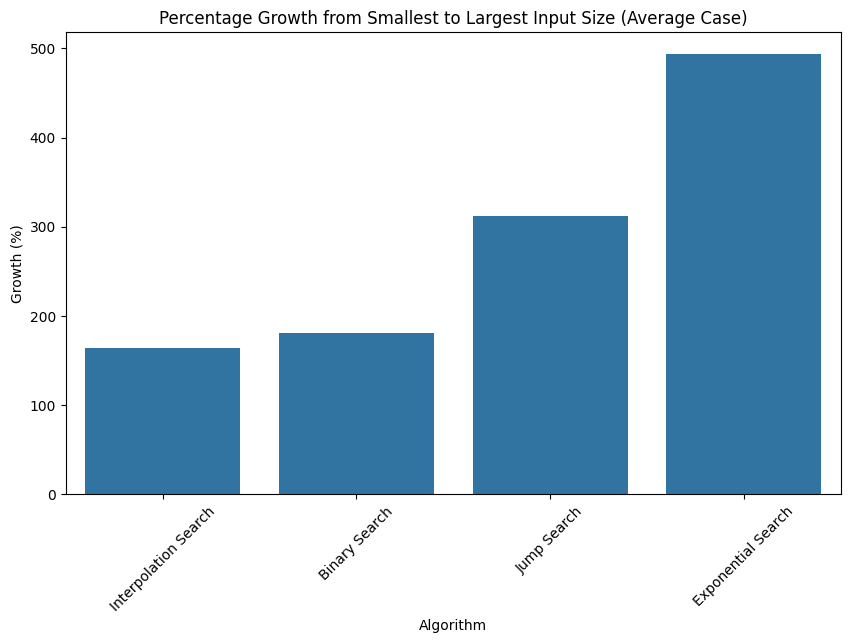

In [11]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=growth_df,
    x="Algorithm",
    y="Growth (%)"
)

plt.title("Percentage Growth from Smallest to Largest Input Size (Average Case)")
plt.xticks(rotation=45)
plt.show()

# Final Conclusions

The experimental evaluation confirms clear performance differences among the analyzed **searching algorithms**.

Because all methods were tested on previously sorted arrays, the measured times represent search performance rather than sorting overhead.

**Binary Search** demonstrates the best overall scalability in the experiment.

**Exponential Search** also performs efficiently, although it tends to be slightly slower than Binary Search.

**Jump Search** remains a valid alternative, but its growth is more noticeable as input size increases.

**Interpolation Search** can perform very well under favorable conditions, especially with uniformly distributed data.

Overall, the experiment validates asymptotic theory and shows that choosing the right search algorithm has a clear impact on performance.
